In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/final_dataset_clean.csv")

df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(21405, 17)


,date,hospital_id,ward_code,base_beds,effective_capacity,occupancy,overflow,admissions,discharges,staffing_index,avg_wait_minutes,admission_rate_per_bed,discharge_rate_per_bed,occupancy_rate,day_of_week,month,date_diff
0,2022-10-29,1,ED,30,34,34,35,62,31,0.938,223,2.067,1.033,1.0,5,10,1 days
1,2022-10-30,1,ED,30,34,34,39,63,28,0.953,275,2.100,0.933,1.0,6,10,1 days
2,2022-11-02,1,ED,30,34,34,32,57,29,0.976,268,1.900,0.967,1.0,2,11,1 days
3,2022-11-03,1,ED,30,34,34,31,61,34,1.002,248,2.033,1.133,1.0,3,11,1 days
4,2022-11-04,1,ED,30,34,34,21,50,33,1.008,249,1.667,1.100,1.0,4,11,1 days


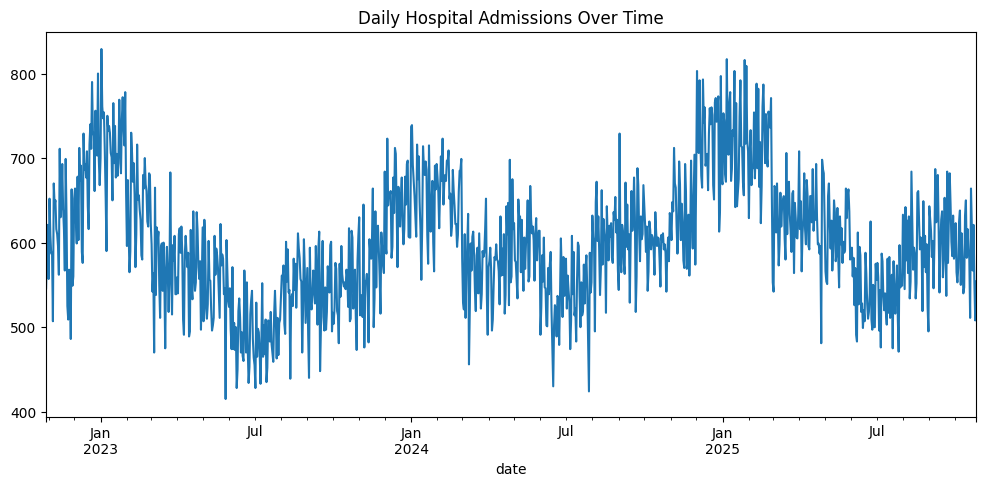

In [3]:
daily_admissions = df.groupby("date")["admissions"].sum()

plt.figure(figsize=(12, 5))
daily_admissions.plot()
plt.title("Daily Hospital Admissions Over Time")
plt.show()

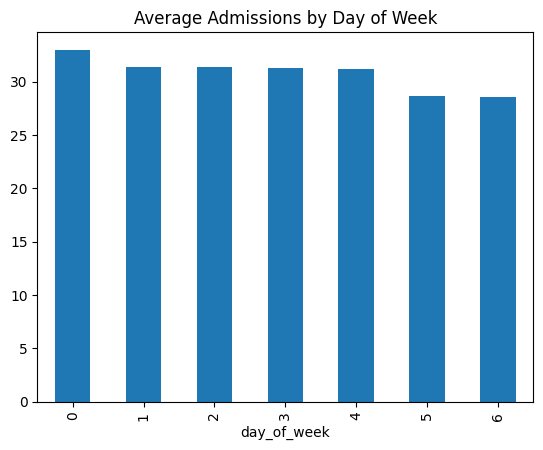

In [4]:
df["day_of_week"] = df["date"].dt.dayofweek

df.groupby("day_of_week")["admissions"].mean().plot(kind="bar")
plt.title("Average Admissions by Day of Week")
plt.show()

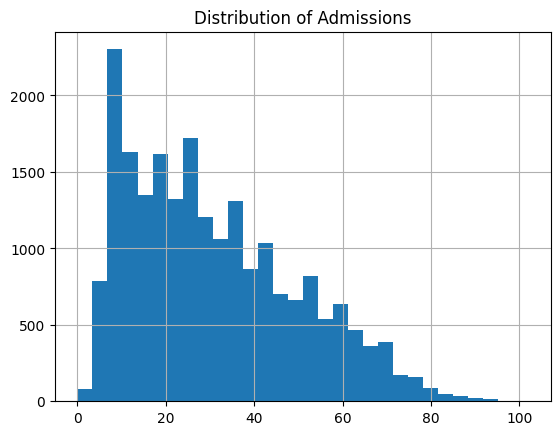

In [5]:
df["admissions"].hist(bins=30)
plt.title("Distribution of Admissions")
plt.show()

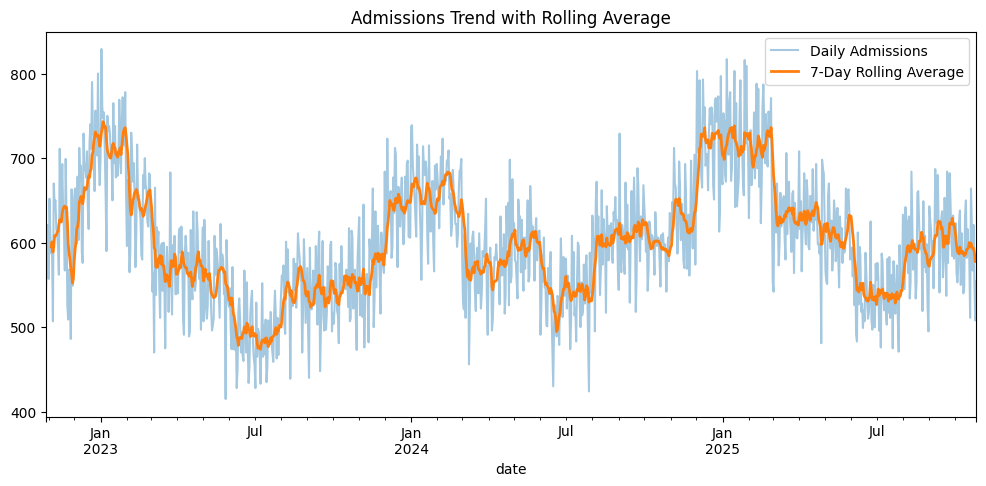

In [6]:
df = df.sort_values("date")

daily_admissions = df.groupby("date")["admissions"].sum()

rolling_mean = daily_admissions.rolling(window=7).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
daily_admissions.plot(alpha=0.4, label="Daily Admissions")
rolling_mean.plot(label="7-Day Rolling Average", linewidth=2)

plt.title("Admissions Trend with Rolling Average")
plt.legend()
plt.show()

In [7]:
import joblib

model = joblib.load("../model/artifacts/admissions_forecast_model.pkl")

with open("../model/artifacts/feature_columns.txt") as f:
    expected_features = [line.strip() for line in f]

print("Loaded model and features:", len(expected_features))

Loaded model and features: 30


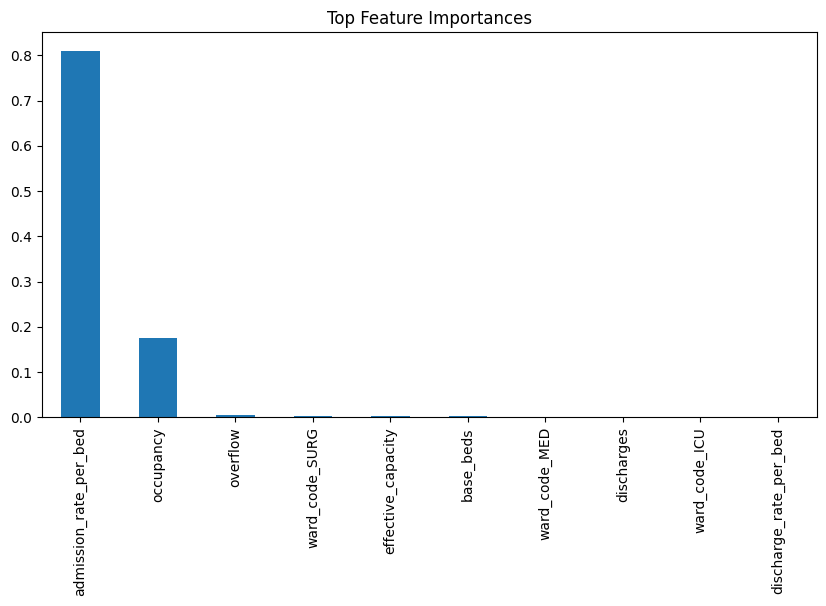

admission_rate_per_bed    0.810422
occupancy                 0.175886
overflow                  0.005588
ward_code_SURG            0.002573
effective_capacity        0.001752
base_beds                 0.001751
ward_code_MED             0.001538
discharges                0.000153
ward_code_ICU             0.000125
discharge_rate_per_bed    0.000052
dtype: float64

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=expected_features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feat_imp.head(10).plot(kind="bar")
plt.title("Top Feature Importances")
plt.show()

feat_imp.head(10)

In [9]:

df_model = pd.read_csv("../data/processed/final_dataset_clean.csv")

df_model = df_model.sort_values("date")

In [10]:
last_row = df_model.iloc[-1].copy()

In [11]:
base_input = pd.DataFrame([last_row])[expected_features]

KeyError: "['year', 'day', 'week_of_year', 'is_weekend', 'hospital_1', 'hospital_2', 'hospital_3', 'hospital_4', 'hospital_5', 'ward_code_ED', 'ward_code_ICU', 'ward_code_MED', 'ward_code_SURG', 'admissions_lag_1', 'admissions_lag_2', 'admissions_lag_3', 'admissions_rolling_mean_3', 'date_diff_1 days'] not in index"

In [ ]:
missing_features = set(expected_features) - set(df_model.columns)
missing_features

{'admissions_lag_1',
 'admissions_lag_2',
 'admissions_lag_3',
 'admissions_rolling_mean_3',
 'day',
 'ward_code_ICU',
 'ward_code_MED',
 'ward_code_SURG',
 'year'}

In [ ]:
df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values(["hospital_id", "date"]).copy()

# one-hot encode ward_code
if "ward_code" in df_model.columns:
    ward_dummies = pd.get_dummies(df_model["ward_code"], prefix="ward_code")
    df_model = pd.concat([df_model, ward_dummies], axis=1)

# lag features
df_model["admissions_lag_1"] = df_model.groupby("hospital_id")["admissions"].shift(1)
df_model["admissions_lag_2"] = df_model.groupby("hospital_id")["admissions"].shift(2)
df_model["admissions_lag_3"] = df_model.groupby("hospital_id")["admissions"].shift(3)

# rolling mean
df_model["admissions_rolling_mean_3"] = (
    df_model.groupby("hospital_id")["admissions"]
    .rolling(window=3)
    .mean()
    .reset_index(level=0, drop=True)
)

# drop rows made incomplete by lagging
df_model = df_model.dropna().reset_index(drop=True)

print(df_model.shape)

(21390, 25)


In [ ]:
import pandas as pd

df_model = pd.read_csv("../data/processed/final_dataset_clean.csv")
df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values(["hospital_id", "date"]).copy()

# one-hot encode ward_code
if "ward_code" in df_model.columns:
    ward_dummies = pd.get_dummies(df_model["ward_code"], prefix="ward_code")
    df_model = pd.concat([df_model, ward_dummies], axis=1)

# create lag features
df_model["admissions_lag_1"] = df_model.groupby("hospital_id")["admissions"].shift(1)
df_model["admissions_lag_2"] = df_model.groupby("hospital_id")["admissions"].shift(2)
df_model["admissions_lag_3"] = df_model.groupby("hospital_id")["admissions"].shift(3)

df_model["admissions_rolling_mean_3"] = (
    df_model.groupby("hospital_id")["admissions"]
    .rolling(window=3)
    .mean()
    .reset_index(level=0, drop=True)
)

df_model = df_model.dropna().reset_index(drop=True)

# make sure all expected features exist
for col in expected_features:
    if col not in df_model.columns:
        df_model[col] = 0

last_row = df_model.iloc[-1].copy()
base_input = pd.DataFrame([last_row])[expected_features]

baseline_pred = model.predict(base_input)[0]
print(f"Baseline prediction: {baseline_pred:.2f}")

Baseline prediction: 16.80


In [ ]:
scenario_1 = base_input.copy()
scenario_1["effective_capacity"] *= 1.10

pred_1 = model.predict(scenario_1)[0]
print(f"Capacity +10% -> Predicted admissions: {pred_1:.2f}")

Capacity +10% -> Predicted admissions: 19.30


In [ ]:
scenario_2 = base_input.copy()
scenario_2["staffing_index"] *= 0.80

pred_2 = model.predict(scenario_2)[0]
print(f"Staffing -20% -> Predicted admissions: {pred_2:.2f}")

Staffing -20% -> Predicted admissions: 16.80


In [ ]:
scenario_3 = base_input.copy()
scenario_3["avg_wait_minutes"] *= 1.20

pred_3 = model.predict(scenario_3)[0]
print(f"Wait time +20% -> Predicted admissions: {pred_3:.2f}")

Wait time +20% -> Predicted admissions: 16.93


## Scenario Analysis Insights

- Increasing effective capacity by 10% resulted in a noticeable increase in predicted admissions, indicating that hospital capacity is a key driver of patient intake.

- Reducing staffing levels by 20% had minimal impact on predicted admissions, suggesting staffing may not be a primary limiting factor in this dataset.

- Increasing average wait time by 20% led to only a slight increase in admissions, indicating it may reflect demand pressure rather than directly influence admissions.

Overall, capacity appears to be the most influential operational factor affecting admissions in this model.

In [12]:
print("Mean:", daily_admissions.mean())
print("Std Dev:", daily_admissions.std())

Mean: 601.5146252285192
Std Dev: 74.41148954803863


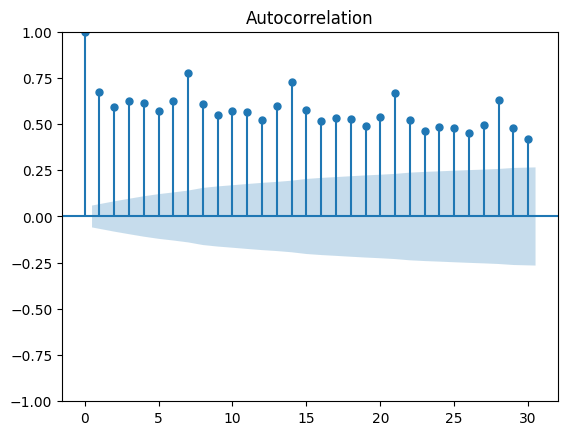

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(daily_admissions, lags=30)
plt.title("Autocorrelation")
plt.show()

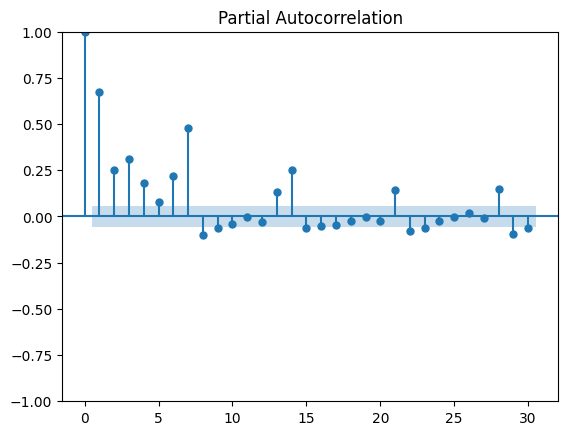

In [14]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(daily_admissions, lags=30)
plt.title("Partial Autocorrelation")
plt.show()

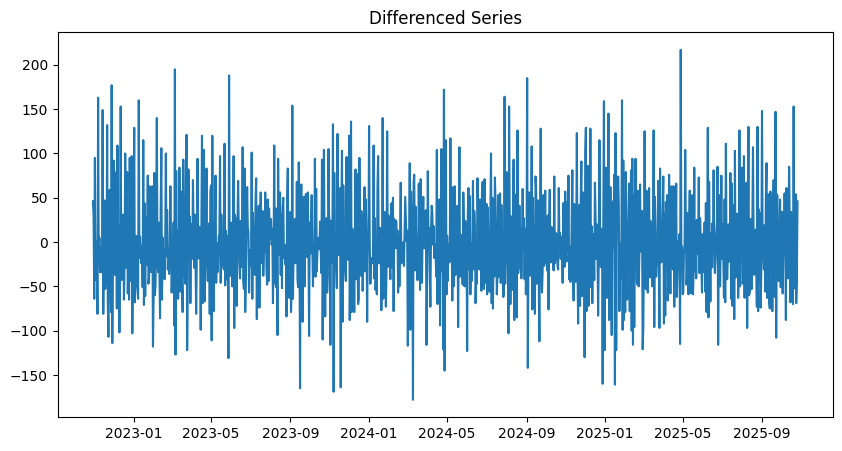

In [15]:
diff_series = daily_admissions.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(diff_series)
plt.title("Differenced Series")
plt.show()

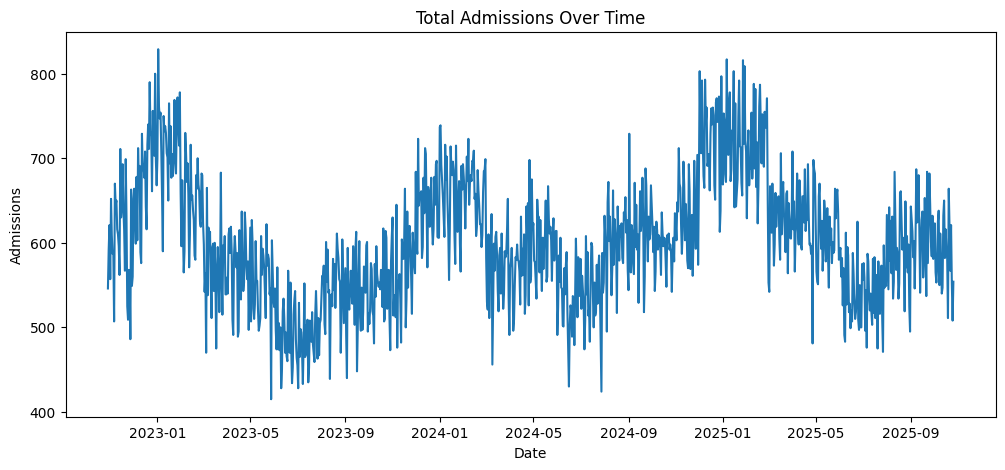

In [16]:
daily_admissions = df.groupby("date")["admissions"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_admissions)
plt.title("Total Admissions Over Time")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.show()

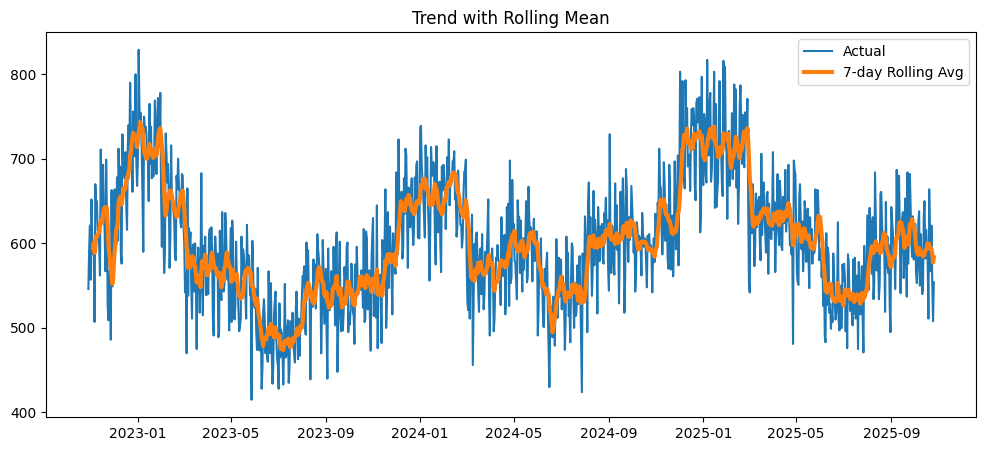

In [18]:
rolling = daily_admissions.rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_admissions, label="Actual")
plt.plot(rolling, label="7-day Rolling Avg", linewidth=3)
plt.legend()
plt.title("Trend with Rolling Mean")
plt.show()

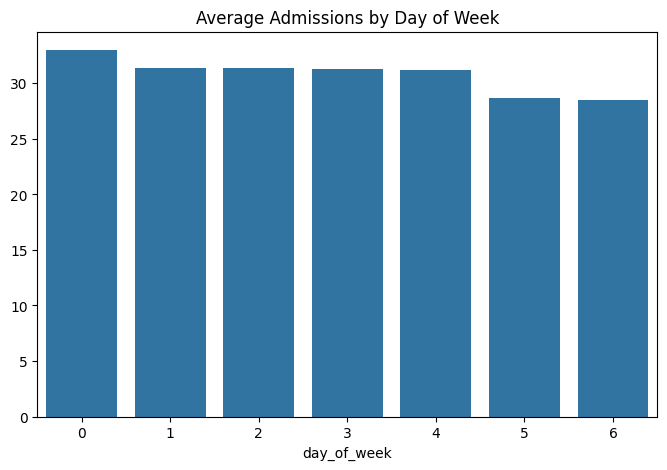

In [19]:
df["day_of_week"] = df["date"].dt.dayofweek

weekly_pattern = df.groupby("day_of_week")["admissions"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values)
plt.title("Average Admissions by Day of Week")
plt.show()

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

daily_admissions = df.groupby("date")["admissions"].sum().sort_index()
daily_admissions = daily_admissions.asfreq("D").interpolate()

train_size = int(len(daily_admissions) * 0.8)
train = daily_admissions.iloc[:train_size]
test = daily_admissions.iloc[train_size:]

candidate_models = [
    {"order": (1, 1, 1), "seasonal_order": (1, 1, 1, 7)},
    {"order": (2, 1, 1), "seasonal_order": (1, 1, 1, 7)},
    {"order": (1, 1, 2), "seasonal_order": (1, 1, 1, 7)},
    {"order": (2, 1, 2), "seasonal_order": (1, 1, 1, 7)},
    {"order": (1, 0, 1), "seasonal_order": (1, 1, 1, 7)},
]

results_summary = []

for config in candidate_models:
    try:
        model = SARIMAX(
            train,
            order=config["order"],
            seasonal_order=config["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False)
        forecast = fitted.forecast(steps=len(test))
        mae = mean_absolute_error(test, forecast)

        results_summary.append({
            "order": config["order"],
            "seasonal_order": config["seasonal_order"],
            "mae": mae
        })

        print(f"Done: {config} -> MAE: {mae:.2f}")

    except Exception as e:
        print(f"Failed: {config} -> {e}")

results_df = pd.DataFrame(results_summary).sort_values("mae")
results_df

Done: {'order': (1, 1, 1), 'seasonal_order': (1, 1, 1, 7)} -> MAE: 56.99
Done: {'order': (2, 1, 1), 'seasonal_order': (1, 1, 1, 7)} -> MAE: 57.00
Done: {'order': (1, 1, 2), 'seasonal_order': (1, 1, 1, 7)} -> MAE: 57.12
Done: {'order': (2, 1, 2), 'seasonal_order': (1, 1, 1, 7)} -> MAE: 56.08
Done: {'order': (1, 0, 1), 'seasonal_order': (1, 1, 1, 7)} -> MAE: 43.49


,order,seasonal_order,mae
4,"(1, 0, 1)","(1, 1, 1, 7)",43.490345
3,"(2, 1, 2)","(1, 1, 1, 7)",56.083619
0,"(1, 1, 1)","(1, 1, 1, 7)",56.990114
1,"(2, 1, 1)","(1, 1, 1, 7)",56.997593
2,"(1, 1, 2)","(1, 1, 1, 7)",57.123669


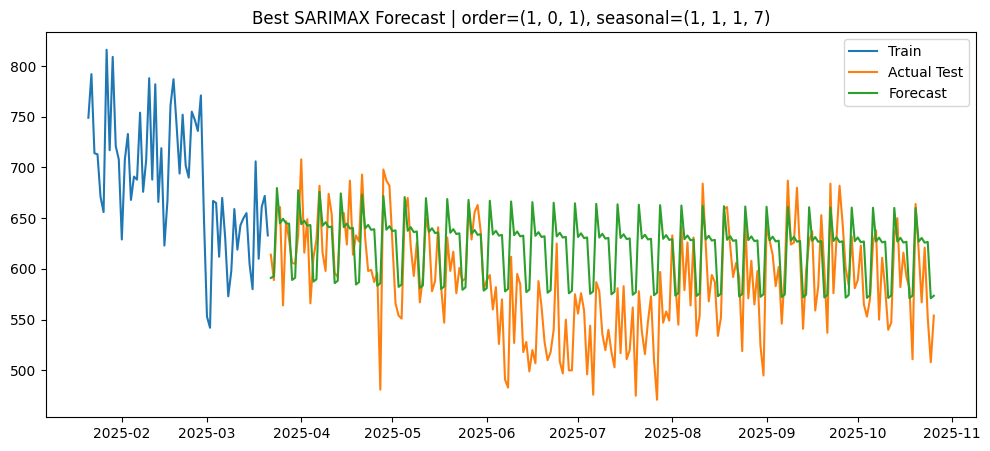

Best order: (1, 0, 1)
Best seasonal_order: (1, 1, 1, 7)


In [21]:
best_order = tuple(results_df.iloc[0]["order"])
best_seasonal = tuple(results_df.iloc[0]["seasonal_order"])

best_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fitted = best_model.fit(disp=False)
best_forecast = best_fitted.forecast(steps=len(test))

plt.figure(figsize=(12, 5))
plt.plot(train.index[-60:], train[-60:], label="Train")
plt.plot(test.index, test, label="Actual Test")
plt.plot(test.index, best_forecast, label="Forecast")
plt.legend()
plt.title(f"Best SARIMAX Forecast | order={best_order}, seasonal={best_seasonal}")
plt.show()

print("Best order:", best_order)
print("Best seasonal_order:", best_seasonal)